# Language Tracking — ITPC Analysis

Measures neural entrainment to speech rhythm via Inter-Trial Phase Coherence (ITPC).  
A healthy brain synchronises its phase to the temporal structure of connected speech at:

| Frequency | Rate | Linguistic level |
| --- | --- | --- |
| **0.78 Hz** | ~1.28 s / sentence | Sentence rate |
| **1.56 Hz** | ~0.64 s | Phrase rate (2× sentence) |
| **3.125 Hz** | ~0.32 s | Word rate |

A **positive finding** is a significant ITPC peak at one or more of these frequencies (p < 0.05 by permutation test), maximal over temporal/fronto-temporal channels.

**Environment:** `stimulus_software/.venv` (MNE 1.11, scipy, pandas, matplotlib)

## 1. Configuration

**How to run this notebook:**

1. Run **cell 1a** — a session dropdown appears. Pick the patient and date. Optionally list bad channels (comma-separated).
2. Run **cell 1b** — reads your selection and sets up all file paths. Check the printed output looks correct.
3. Click on cell 1b, then choose **Run → Run Selected Cell and All Below** from the menu to execute the rest of the notebook in one go.

> To switch patients mid-session: change the dropdown, re-run cell 1b, then use **Run → Run Selected Cell and All Below** again.

In [1]:
import sys
import re
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

ANALYSIS_ROOT = Path.cwd().resolve()
if ANALYSIS_ROOT.name != 'analysis':
    ANALYSIS_ROOT = next(
        (parent for parent in [ANALYSIS_ROOT, *ANALYSIS_ROOT.parents]
         if parent.name == 'analysis' and (parent / 'notebooks').exists()),
        ANALYSIS_ROOT,
    )
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))

from lib.io import DEFAULT_EEG_CHANNELS

repo_root = ANALYSIS_ROOT.parent
csv_dir = repo_root / 'stimulus_software' / 'patient_data' / 'results'
edf_dir = repo_root / 'stimulus_software' / 'patient_data' / 'edfs'

edf_by_patient = {
    f.name.replace('_clipped.EDF', '').replace('_clipped.edf', ''): f
    for f in sorted(edf_dir.glob('*.[Ee][Dd][Ff]'))
    if '_clipped' in f.name
}

def _parse_csv(path):
    m = re.search(r'(\d{4}-\d{2}-\d{2})_stimulus_results', path.stem)
    if not m:
        return None
    date = m.group(1)
    patient_id = path.stem[:path.stem.index('_' + date)]
    return patient_id, date

sessions = []
for f in sorted(csv_dir.glob('*_stimulus_results.csv')):
    parsed = _parse_csv(f)
    if parsed is None:
        continue
    pid, date = parsed
    sessions.append({'csv': f, 'patient_id': pid, 'date': date, 'edf': edf_by_patient.get(pid)})

options = [(f'{s["patient_id"]}  —  {s["date"]}', i) for i, s in enumerate(sessions)]

csv_dropdown = widgets.Dropdown(
    options=options,
    description='Session:',
    layout=widgets.Layout(width='360px'),
    style={'description_width': 'initial'},
)
edf_status = widgets.Label()

def _on_change(_):
    s = sessions[csv_dropdown.value]
    edf_status.value = f'EDF: {s["edf"].name}' if s['edf'] else '⚠  No matching EDF found for this patient'

csv_dropdown.observe(_on_change, names='value')
_on_change(None)

display(csv_dropdown, edf_status)
print('Select a session above, then run the next cell.')

Dropdown(description='Session:', layout=Layout(width='360px'), options=(('CON010  —  2026-03-06', 0), ('CON011…

Label(value='EDF: CON010_clipped.EDF')

Select a session above, then run the next cell.


### 1b. Confirm selection — run after choosing from the dropdown above

In [ ]:
_sel = sessions[csv_dropdown.value]
SUBJECT_ID   = _sel['patient_id']
SESSION_DATE = _sel['date']
CSV_PATH     = _sel['csv']
EDF_PATH     = _sel['edf']

if EDF_PATH is None or not EDF_PATH.exists():
    raise FileNotFoundError(
        f'No EDF found for {SUBJECT_ID} — '
        f'add {SUBJECT_ID}_clipped.EDF to patient_data/edfs/'
    )

OUT_DIR = ANALYSIS_ROOT / 'results' / SUBJECT_ID / 'language'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EEG_CHANNELS = DEFAULT_EEG_CHANNELS.copy()
BAD_CHANNELS = []

print(f'Subject:    {SUBJECT_ID}')
print(f'Date:       {SESSION_DATE}')
print(f'EDF:        {EDF_PATH.name}')
print(f'CSV:        {CSV_PATH.name}')
print(f'Output dir: {OUT_DIR}')

## 2. Imports

In [3]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy import stats

from lib.io import align_stimulus_csv, load_raw_eeg_metadata
from lib.preprocessing import load_filtered_eeg

%matplotlib inline
mne.set_log_level('WARNING')
print(f'MNE {mne.__version__}')

MNE 1.11.0


## 3. Load EDF + Sync Alignment

In [4]:
raw, sfreq, available_eeg = load_raw_eeg_metadata(
    EDF_PATH,
    eeg_channels=EEG_CHANNELS,
    bad_channels=BAD_CHANNELS,
    preload=False,
    verbose=False,
)
print(f'EEG channels ({len(available_eeg)}): {available_eeg}')
print(f'sfreq: {sfreq} Hz  |  duration: {raw.n_times/sfreq:.0f}s')

EEG channels (19): ['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'T5', 'T6', 'Pz', 'P3', 'P4', 'O1', 'O2']
sfreq: 512.0 Hz  |  duration: 4846s


/Users/joey/Documents/EEG Project/code/analysis/lib/io.py:93: RuntimeWarning: Omitted 5 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=verbose)
/Users/joey/Documents/EEG Project/code/analysis/lib/io.py:102: RuntimeWarning: The unit for channel(s) DC10, DC2, DC3, DC4, DC5, DC6, DC7, DC8, DC9 has changed from V to NA.
  raw.set_channel_types({ch: "misc" for ch in dc_channels})


In [5]:
df, time_offset = align_stimulus_csv(CSV_PATH, sfreq=sfreq, n_times=raw.n_times)
print(f'time_offset = {time_offset:.4f} s')

time_offset = -1828.7082 s


## 4. Preprocessing

In [6]:
# Narrow band-pass for ITPC (speech frequencies are below 5 Hz)
raw_lang = load_filtered_eeg(raw, available_eeg, l_freq=0.1, h_freq=25, verbose=False)
print('Preprocessing done.')

Preprocessing done.


## 5. Epoch

In [7]:
lang_df = df[df['stim_type'] == 'language'].copy()
print(f'Language trials: {len(lang_df)}')
dur = lang_df['edf_end'] - lang_df['edf_start']
print(f'Duration: mean={dur.mean():.2f}s  min={dur.min():.2f}s  max={dur.max():.2f}s')

# Epoch length: use the minimum actual trial duration, capped at 15.36s (12 × 1.28s expected).
#
# Pause/resume safety: stimulus_software replays the entire language stimulus from scratch on
# resume and does NOT log the interrupted play to the CSV. All rows here represent complete
# plays — there is no partial-epoch risk from pausing.
#
# We still clamp to the observed minimum duration in case sentence audio lengths differ from
# the 1.28s assumption, so no epoch runs past its trial's actual end.
EPOCH_TMAX = min(15.36, float(dur.min()))
if dur.min() < 14.0:
    print(f'WARNING: shortest trial is {dur.min():.2f}s — check for truncated runs or unexpected audio lengths.')
print(f'Epoch tmax: {EPOCH_TMAX:.2f}s')

lang_events = np.column_stack([
    lang_df['start_sample'].values,
    np.zeros(len(lang_df), dtype=int),
    np.ones(len(lang_df), dtype=int)
])

epochs = mne.Epochs(raw_lang, events=lang_events, event_id={'language': 1},
                    tmin=0, tmax=EPOCH_TMAX, baseline=None, preload=True, verbose=False)
epochs.resample(256, verbose=False)

print(f'Epochs: {len(epochs)} trials × {len(epochs.ch_names)} ch × {epochs.get_data().shape[2]} samples')

Language trials: 72
Duration: mean=15.38s  min=15.37s  max=15.38s
Epoch tmax: 15.36s
Epochs: 72 trials × 19 ch × 3932 samples


## 6. Compute ITPC

In [8]:
def compute_itpc(epochs_data, fs):
    """Returns itpc (n_samples, n_channels) and freq axis."""
    data = np.transpose(epochs_data, (2, 1, 0))  # (n_samples, n_ch, n_trials)
    freqs = np.fft.fftfreq(data.shape[0], 1 / fs)
    itpc = np.abs(np.exp(1j * np.angle(fft(data, axis=0))).mean(axis=2))
    return itpc, freqs

print(f'Computing ITPC on {len(epochs)} trials...')
itpc, freqs = compute_itpc(epochs.get_data(), fs=epochs.info['sfreq'])
print('Done.')

Computing ITPC on 72 trials...
Done.


## 7. Permutation Test

Shuffle trial labels 1000× to build a null distribution. Compare observed ITPC at each target frequency to the null.

In [9]:
N_PERMS = 1000
TARGET_FREQS = [0.78, 1.56, 3.125]

epochs_data = epochs.get_data()
fs = epochs.info['sfreq']

observed = {}
for f in TARGET_FREQS:
    idx = np.argmin(np.abs(freqs - f))
    observed[f] = itpc[idx, :].mean()

print(f'Running {N_PERMS} permutations...')
null = {f: [] for f in TARGET_FREQS}
rng = np.random.default_rng(42)

for _ in range(N_PERMS):
    shuffled = epochs_data[rng.permutation(len(epochs_data))]
    perm_itpc, _ = compute_itpc(shuffled, fs)
    for f in TARGET_FREQS:
        idx = np.argmin(np.abs(freqs - f))
        null[f].append(perm_itpc[idx, :].mean())

print('\nResults:')
print(f'{"Frequency":>12}  {"Observed":>10}  {"Null mean":>10}  {"p-value":>10}  {"Significant":>12}')
results = {}
for f in TARGET_FREQS:
    obs = observed[f]
    null_arr = np.array(null[f])
    p = np.mean(null_arr >= obs)
    sig = '✓' if p < 0.05 else ''
    results[f] = {'observed': obs, 'null_mean': null_arr.mean(), 'p_value': p}
    print(f'{f:>12.3f}  {obs:>10.4f}  {null_arr.mean():>10.4f}  {p:>10.4f}  {sig:>12}')

Running 1000 permutations...

Results:
   Frequency    Observed   Null mean     p-value   Significant
       0.780      0.0472      0.0472      0.6040              
       1.560      0.0870      0.0870      0.1860              
       3.125      0.1221      0.1221      0.2780              


## 8. Plots

In [ ]:
fmin, fmax = 0.5, 4.0
pos_idx = (freqs >= fmin) & (freqs <= fmax)
plot_freqs = freqs[pos_idx]
avg_itpc = itpc[pos_idx, :].mean(axis=1)

TARGETS = [(0.78, 'teal', '0.78 Hz'), (1.56, 'darkorchid', '1.56 Hz'), (3.125, 'firebrick', '3.125 Hz')]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_freqs, avg_itpc, color='steelblue', lw=1.5, label='Observed ITPC')

null_95 = {}
for f, _, _ in TARGETS:
    null_95[f] = np.percentile(null[f], 95)

for f, c, lbl in TARGETS:
    p = results[f]['p_value']
    marker = ' *' if p < 0.05 else ''
    ax.axvspan(f - 0.04, f + 0.04, color=c, alpha=0.2, label=f'{lbl}{marker} (p={p:.3f})')
    ax.axhline(null_95[f], color=c, lw=0.8, ls=':', alpha=0.6)

ax.set(xlabel='Frequency (Hz)', ylabel='ITPC',
       title=f'{SUBJECT_ID} — Language ITPC (avg across {len(available_eeg)} channels)',
       xlim=(fmin, fmax))
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_lang_itpc_avg.png', dpi=150)
plt.show()

NameError: name 'plot_freqs' is not defined

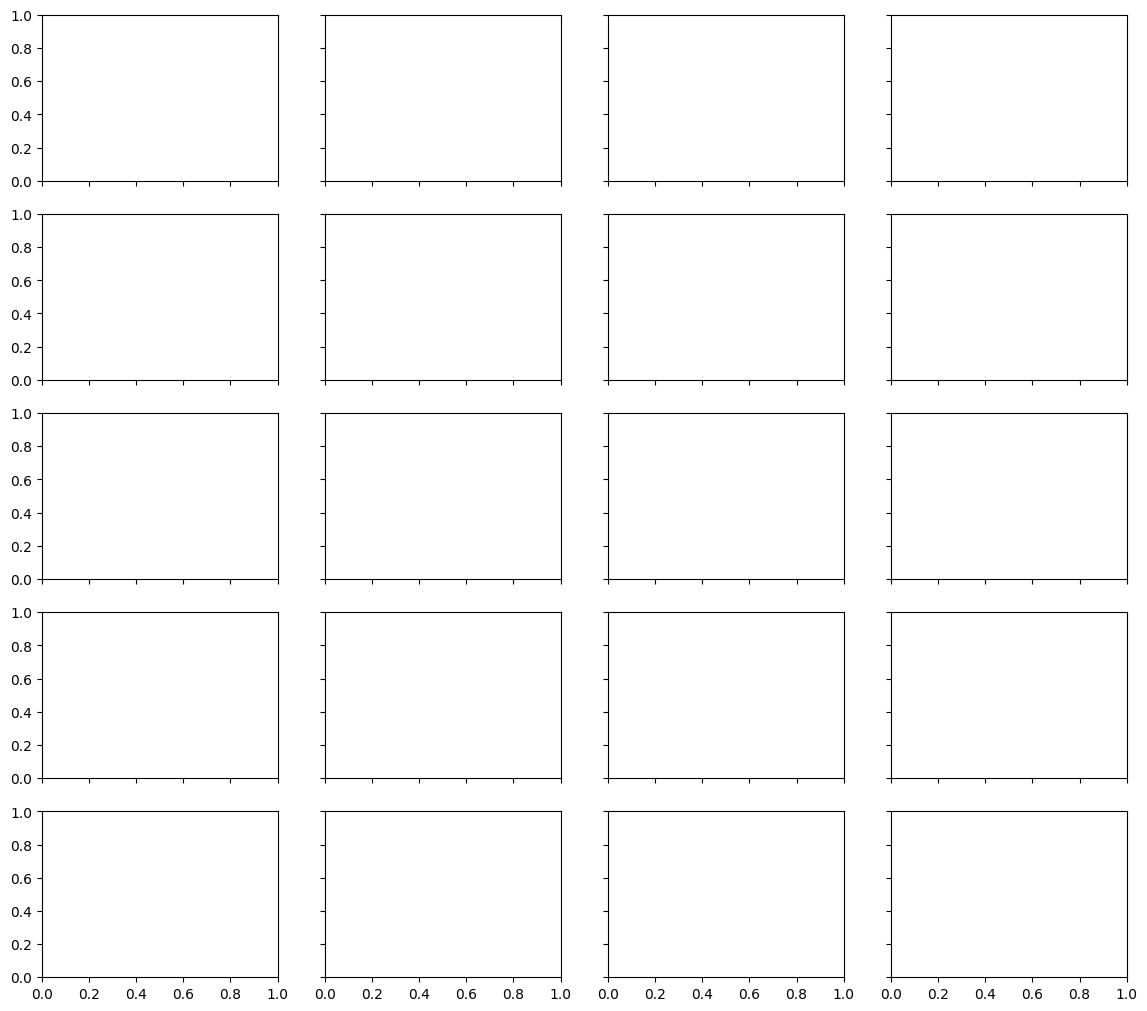

In [12]:
n_ch = len(epochs.ch_names)
ncols = 4
nrows = (n_ch + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.5 * nrows), sharex=True, sharey=True)
for i, ch_name in enumerate(epochs.ch_names):
    ax = axes.flatten()[i]
    ax.plot(plot_freqs, itpc[pos_idx, i], color='steelblue', lw=1)
    for f, c, _ in TARGETS:
        ax.axvspan(f - 0.04, f + 0.04, color=c, alpha=0.2)
    ax.set_title(ch_name, fontsize=9)
    ax.grid(True, alpha=0.2)
for j in range(i + 1, len(axes.flatten())):
    axes.flatten()[j].set_visible(False)
fig.suptitle(f'{SUBJECT_ID} — Language ITPC per channel', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_lang_itpc_channels.png', dpi=120)
plt.show()

In [ ]:
montage = mne.channels.make_standard_montage('standard_1020')
epochs.set_montage(montage, match_case=False, on_missing='warn')

fig, axes = plt.subplots(1, len(TARGETS), figsize=(4 * len(TARGETS), 4))
for ax, (f, c, lbl) in zip(axes, TARGETS):
    idx = np.argmin(np.abs(freqs - f))
    ch_itpc = itpc[idx, :]
    im, _ = mne.viz.plot_topomap(ch_itpc, epochs.info, axes=ax, show=False,
                                  vlim=(0, ch_itpc.max()), cmap='hot_r')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    p = results[f]['p_value']
    ax.set_title(f'{lbl}  (p={p:.3f})', fontsize=10)
fig.suptitle(f'{SUBJECT_ID} — Language ITPC topomap', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'{SUBJECT_ID}_lang_itpc_topomap.png', dpi=150)
plt.show()

## 9. Summary

**Positive finding:** ITPC peak at 0.78 Hz and/or 1.56 Hz, p < 0.05, maximal over temporal channels (T3/T4/T5/T6).  
**Clinical interpretation:** Preserved covert language comprehension.